# Urban Similarity Model Analysis - São Paulo

This notebook loads the primary district attributes, applies transformations, computes the family distances for the reference district (Brás), and plots the similarity results.

## Math and Techniques

To establish a mathematically rigorous comparison between districts, we use a 13-dimensional feature space combining Morphology (M), Buildings (B), and Urban Functions (U).

### Transformations
- **Logarithmic (`ln(x)` or `ln(1+x)`)**: Applied to highly skewed variables such as density measures (e.g. `street_density_km_km2`, `population_density_km2`) to express relative differences and reduce extreme magnitude domination.
- **Identity**: Applied to fractions or values already on a comparable scale (e.g., `building_coverage_land`, `land_use_entropy_count`).
- **Composition Normalization**: For categorical shares (e.g., Street Classes), we normalize the shares to sum to 1 and take their square root to compute the Hellinger distance.

### Scaling
We use **Robust Scaling** for non-composition variables. For each transformed scalar feature $j$, we fit the median $m_j$ and the interquartile range $s_j = Q75 - Q25$. 
$$z_{dj} = (t(x_{dj}) - m_j) / s_j$$
If the IQR is zero (e.g., `cadastral_floor_count_p90`), we fallback to the population standard deviation.

### Distance Metrics
- **Within-family scalar distance**: We calculate the mean squared standardized difference for coordinates in the family.
- **Hellinger distance**: Used for composition features (e.g., M6), calculated as $0.5 \sum (\sqrt{p_{dc}} - \sqrt{p_{ec}})^2$.
- **Family Calibration**: Each family distance is scaled by its median positive pairwise distance $b_f$ to make variations comparable across domains.
- **Overall Distance**: A weighted Euclidean distance integrating all families.


## Attribute Data Dictionary

The model uses 23 primary columns categorized into 13 Feature Families across three broad domains: **Morphology (M)**, **Buildings (B)**, and **Urban Functions (U)**.

**Morphology ($M$)**
*   **M1 (Street density)**: `street_density_km_km2` — Amount of mapped street linework length relative to district gross area.
*   **M2 (Intersection-density proxy)**: `intersection_density_proxy_5m_km2` — Density of street junction candidates, excluding grade-separated structures like bridges and tunnels.
*   **M3 (Block size)**: `block_log_area_median`, `block_log_area_iqr` — Distribution summaries of eligible cadastral block sizes.
*   **M4 (Block shape)**: `block_compactness_median/iqr`, `block_elongation_median/iqr` — Compactness (area/perimeter ratio) and elongation (bounding box ratio) of blocks.
*   **M6 (Street-class composition)**: `street_class_model_share_*` — The mix of road types (arterial, coletora, local, rodovia, via_de_pedestres, vtr) treated jointly as a compositional vector.
*   **M7 (Cadastral parcel density)**: `cadastral_parcel_density_km2` — Number of accepted cadastral land parcels per square kilometer.

**Buildings ($B$)**
*   **B1 (Building footprint coverage)**: `building_coverage_land` — Fraction of district land strictly occupied by mapped 2D building footprints.
*   **B2 (Cadastral floor-count distribution)**: `cadastral_floor_count_median`, `cadastral_floor_count_p90` — Typical and upper-tail reported floors from fiscal records.
*   **B3 (Cadastral constructed-area density)**: `cadastral_floor_area_density` — Total built floor-space intensity relative to district land area.

**Urban Functions ($U$)**
*   **U1 (Cadastral land-use composition)**: `land_use_entropy_count` — Diversity (entropy) representing the mix of 7 cadastral land-use categories (e.g., residential, commercial, industrial).
*   **U2 (Formal employment density)**: `formal_job_density_area_first_km2` — Intensity of RAIS 2022 formal jobs allocated to the district's footprint.
*   **U3 (Population density)**: `population_density_km2` — Residents per square kilometer based on the 2022 Census.
*   **U4 (Population-weighted expected bus-service access)**: `bus_service_access_weekday_am_400m` — Expected nearby bus departures accessible per resident over a standard 2-hour window.


In [81]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
from pathlib import Path
from math import pi

# Configure plotting
plt.style.use('seaborn-v0_8-whitegrid')
%matplotlib inline


In [82]:
base_dir = Path('.')
config_path = base_dir / 'config/sp_urban_model_v1.json'

with open(config_path, 'r') as f:
    config = json.load(f)

primary_path = base_dir / config['paths']['primary_attributes']
df = pd.read_csv(primary_path, dtype={'district_id': str})
df.set_index('district_id', inplace=True)
print(f"Loaded {len(df)} districts.")
df.head()


Loaded 96 districts.


,block_compactness_iqr,block_compactness_median,block_elongation_iqr,block_elongation_median,block_log_area_iqr,block_log_area_median,building_coverage_land,bus_service_access_weekday_am_400m,cadastral_floor_area_density,cadastral_floor_count_median,...,land_use_entropy_count,population_density_km2,street_class_model_share_arterial,street_class_model_share_coletora,street_class_model_share_local,street_class_model_share_rodovia,street_class_model_share_via_de_pedestres,street_class_model_share_vtr,street_density_km_km2,district_name
district_id,,,,,,,,,,,,,,,,,,,,,
01,0.239649,0.640560,1.303688,1.982539,0.927742,9.313142,0.500489,199.276061,0.876396,2.0,...,0.425269,11990.173578,0.141830,0.278437,0.578004,0.00000,0.001729,0.0,22.883474,AGUA RASA
02,0.186134,0.642715,1.174838,2.111770,0.686438,9.471606,0.301528,100.382296,0.680230,2.0,...,0.299919,4938.885461,0.088615,0.173260,0.733740,0.00000,0.004385,0.0,19.496301,ALTO DE PINHEIROS
03,0.276936,0.542349,1.608270,2.499280,1.365122,8.644468,0.065368,59.965944,0.050148,2.0,...,0.389875,2266.256178,0.010596,0.036831,0.892612,0.05362,0.006341,0.0,6.396345,ANHANGUERA
04,0.184774,0.640338,1.335033,2.283053,0.734945,8.846979,0.478544,264.531071,0.579532,2.0,...,0.385263,13044.148817,0.087582,0.209347,0.692423,0.00000,0.010647,0.0,23.224739,ARICANDUVA
05,0.180441,0.655013,1.218891,2.246580,0.654469,9.017710,0.393220,263.335999,0.489799,1.0,...,0.347605,14737.143337,0.085457,0.248532,0.650962,0.00000,0.015050,0.0,22.846217,ARTUR ALVIM


## Transform & Compute Distances
Applying the mathematical transforms specified in the plan...


In [83]:
# 1. Transform Scalars
scalar_cols = []
t_df = pd.DataFrame(index=df.index)
for fam, f_config in config['families'].items():
    if f_config['type'] == 'scalar':
        for col in f_config['columns']:
            x = df[col].astype(float)
            if f_config['transform'] == 'log': x = np.log(x)
            elif f_config['transform'] == 'log1p': x = np.log1p(x)
            
            med, iqr = x.median(), x.quantile(0.75) - x.quantile(0.25)
            scale = iqr if iqr > 1e-12 else x.std(ddof=0)
            t_df[col] = (x - med) / scale
            scalar_cols.append(col)

# 2. Transform Composition (M6)
comp_cols = config['families']['M6']['columns']
mat = df[comp_cols].values
mat = mat / mat.sum(axis=1)[:, np.newaxis] # Normalize
sqrt_mat = np.sqrt(mat)
for i, col in enumerate(comp_cols):
    t_df[col] = sqrt_mat[:, i]

# 3. Compute Distances to Brás ('10')
bras_id = config['target_district_id']
n = len(t_df)
dists = {fam: np.zeros(n) for fam in config['families']}
calibrations = {}

for fam, f_config in config['families'].items():
    cols = f_config['columns']
    fam_data = t_df[cols].values
    bras_data = t_df.loc[bras_id, cols].values
    
    # Calculate all pairs to find calibration median
    all_mat = np.zeros((n, n))
    if f_config['type'] == 'scalar':
        for i in range(n):
            for j in range(n):
                all_mat[i, j] = np.sum((fam_data[i] - fam_data[j])**2) / len(cols)
    else:
        for i in range(n):
            for j in range(n):
                all_mat[i, j] = 0.5 * np.sum((fam_data[i] - fam_data[j])**2)
                
    pos_dists = all_mat[np.triu_indices(n, k=1)]
    calibrations[fam] = np.median(pos_dists[pos_dists > 0])
    
    # Brás distances
    for i in range(n):
        if f_config['type'] == 'scalar':
            dists[fam][i] = np.sum((fam_data[i] - bras_data)**2) / len(cols)
        else:
            dists[fam][i] = 0.5 * np.sum((fam_data[i] - bras_data)**2)

# Total Distance
total_dist = np.zeros(n)
contributions = {}
for fam in config['families']:
    w_f = config['families'][fam]['weight'] / 13.0
    c_arr = w_f * dists[fam] / calibrations[fam]
    contributions[fam] = c_arr
    total_dist += c_arr

total_dist = np.sqrt(total_dist)

res = pd.DataFrame({'distance': total_dist}, index=df.index)
res['district_name'] = df['district_name']
res = res.drop(bras_id).sort_values('distance')
res['rank'] = res['distance'].rank(method='min').astype(int)
print("Top 10 similar districts to Brás:")
display(res[['district_name', 'distance', 'rank']].head(10))


Top 10 similar districts to Brás:


,district_name,distance,rank
district_id,,,
08,BELEM,0.537614,1
09,BOM RETIRO,0.627889,2
14,CAMBUCI,0.681758,3
62,PINHEIROS,0.764482,4
53,MOOCA,0.832456,5
80,TATUAPE,0.846557,6
49,LIBERDADE,0.868025,7
48,LAPA,0.891913,8
90,VILA MARIANA,0.925813,9


## Visualizing Results
### Breakdown of Squared Distance for Top 10 Neighbors


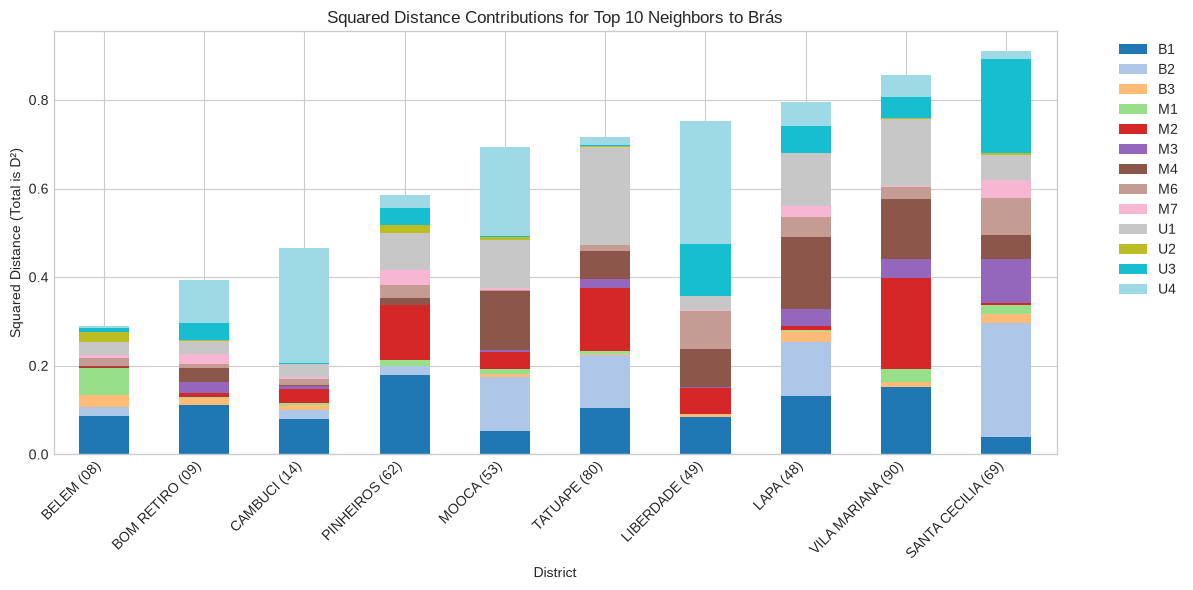

In [84]:
top_10 = res.head(10).index

# Prepare contribution data
plot_data = []
for d_id in top_10:
    idx = df.index.get_loc(d_id)
    dist_name = df.loc[d_id, 'district_name']
    for fam in config['families']:
        plot_data.append({
            'District': f"{dist_name} ({d_id})",
            'Family': fam,
            'Contribution': contributions[fam][idx]
        })

contrib_df = pd.DataFrame(plot_data)
contrib_pivot = contrib_df.pivot(index='District', columns='Family', values='Contribution')
# Sort index by distance
sorted_labels = [f"{df.loc[d_id, 'district_name']} ({d_id})" for d_id in top_10]
contrib_pivot = contrib_pivot.reindex(sorted_labels)

plt.figure(figsize=(12, 6))
contrib_pivot.plot(kind='bar', stacked=True, colormap='tab20', ax=plt.gca())
plt.title('Squared Distance Contributions for Top 10 Neighbors to Brás')
plt.ylabel('Squared Distance (Total is D²)')
plt.xlabel('District')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


In [85]:
import geopandas as gpd

# Load geometry
geo_path = base_dir / config['paths']['district_geometry']
gdf = gpd.read_file(geo_path)
gdf['district_id'] = gdf['district_id'].astype(str)

# Merge distance and rank to the geodataframe
gdf = gdf.merge(res[['distance', 'rank']], on='district_id', how='left')

# Filter geometries
top10_gdf = gdf[gdf['rank'] <= 10]
bras_gdf = gdf[gdf['district_id'] == bras_id]

# Create a neutral base map for all districts
m = gdf.explore(
    tiles='OpenStreetMap',
    tooltip=['district_name', 'distance', 'rank'],
    style_kwds={'weight': 1, 'color': 'gray', 'fillOpacity': 0.1, 'fillColor': '#e0e0e0'}
)

# Highlight top 10 districts
m = top10_gdf.explore(
    m=m,
    style_kwds={'weight': 3, 'fillOpacity': 0.4, 'color': 'red', 'fillColor': 'red'},
    tooltip=['district_name', 'rank', 'distance']
)

# Highlight Brás
m = bras_gdf.explore(
    m=m,
    style_kwds={'weight': 4, 'fillOpacity': 0.4, 'color': 'blue', 'fillColor': 'blue'},
    tooltip=['district_name']
)

m


### Radar Chart Comparison: Brás vs Top Match
We compare the standardized coordinates of Brás and its #1 Top Match to see on which axes they align or diverge.


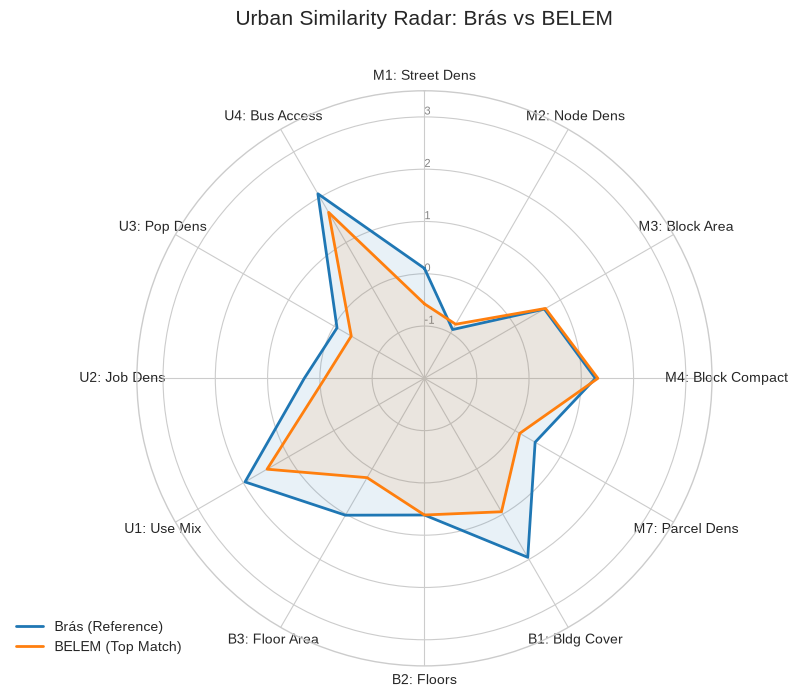

In [86]:
top_match_id = top_10[0]
top_match_name = df.loc[top_match_id, 'district_name']
bras_name = "Brás"

# We select one representative variable per family for simplicity in the radar chart
radar_cols = {
    'M1: Street Dens': 'street_density_km_km2',
    'M2: Node Dens': 'intersection_density_proxy_5m_km2',
    'M3: Block Area': 'block_log_area_median',
    'M4: Block Compact': 'block_compactness_median',
    'M7: Parcel Dens': 'cadastral_parcel_density_km2',
    'B1: Bldg Cover': 'building_coverage_land',
    'B2: Floors': 'cadastral_floor_count_median',
    'B3: Floor Area': 'cadastral_floor_area_density',
    'U1: Use Mix': 'land_use_entropy_count',
    'U2: Job Dens': 'formal_job_density_area_first_km2',
    'U3: Pop Dens': 'population_density_km2',
    'U4: Bus Access': 'bus_service_access_weekday_am_400m'
}

categories = list(radar_cols.keys())
N = len(categories)

# Extract and standardize the values just for visualization
raw_subset = df[list(radar_cols.values())].astype(float)
scaled_subset = (raw_subset - raw_subset.mean()) / raw_subset.std()

val_bras = scaled_subset.loc[bras_id].values.tolist()
val_top = scaled_subset.loc[top_match_id].values.tolist()

# Close the loop
val_bras += val_bras[:1]
val_top += val_top[:1]
angles = [n / float(N) * 2 * pi for n in range(N)]
angles += angles[:1]

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))

ax.set_theta_offset(pi / 2)
ax.set_theta_direction(-1)
plt.xticks(angles[:-1], categories, size=10)

# Set y-limits
ax.set_rlabel_position(0)
plt.yticks([-2, -1, 0, 1, 2, 3], ["-2", "-1", "0", "1", "2", "3"], color="grey", size=8)
plt.ylim(-2, 3.5)

# Plot Brás
ax.plot(angles, val_bras, linewidth=2, linestyle='solid', label=f"{bras_name} (Reference)")
ax.fill(angles, val_bras, alpha=0.1)

# Plot Top Match
ax.plot(angles, val_top, linewidth=2, linestyle='solid', label=f"{top_match_name} (Top Match)")
ax.fill(angles, val_top, alpha=0.1)

plt.title(f"Urban Similarity Radar: {bras_name} vs {top_match_name}", size=15, y=1.1)
plt.legend(loc='upper right', bbox_to_anchor=(0.1, 0.1))
plt.tight_layout()
plt.show()


## Principal Component Analysis (PCA) & Attribute Variance

Since this is an **unsupervised similarity model** (we do not have a "target" variable to predict), supervised algorithms like Random Forest cannot be directly used to rank feature importance. 

However, we can use **PCA (Principal Component Analysis)** on the full set of transformed 23 variables to understand the structural variance of the entire dataset. PCA will tell us which attributes drive the most variation across all of São Paulo's districts.


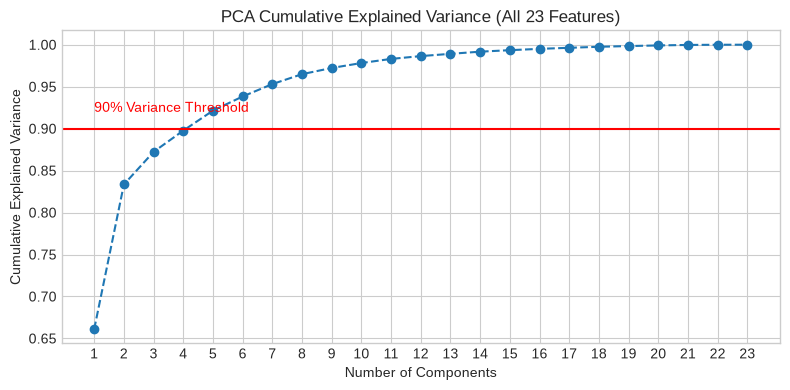

In [87]:
# We calculate PCA from scratch using numpy SVD (ensures no sklearn dependency issues)
# Build the primary embedding as per Section 5.2
E_df = pd.DataFrame(index=t_df.index)
for fam, f_config in config['families'].items():
    cols = f_config['columns']
    w_f = f_config['weight'] / 13.0
    b_f = calibrations[fam]
    if f_config['type'] == 'scalar':
        k_f = len(cols)
        scale_factor = np.sqrt(w_f / (k_f * b_f))
    else: # M6 composition
        scale_factor = np.sqrt(w_f / (2.0 * b_f))
    for col in cols:
        E_df[col] = t_df[col] * scale_factor

X = E_df.values
X_centered = X - X.mean(axis=0)
U, S, Vt = np.linalg.svd(X_centered, full_matrices=False)

# Variance calculations
eigenvalues = (S ** 2) / (len(X) - 1)
explained_var = eigenvalues / eigenvalues.sum()
cumulative_var = np.cumsum(explained_var)

# Plot Explained Variance
plt.figure(figsize=(8, 4))
plt.plot(range(1, len(explained_var)+1), cumulative_var, marker='o', linestyle='--')
plt.title('PCA Cumulative Explained Variance (All 23 Features)')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.axhline(y=0.90, color='r', linestyle='-')
plt.text(1, 0.92, '90% Variance Threshold', color='red')
plt.xticks(range(1, len(explained_var)+1))
plt.tight_layout()
plt.show()


In [88]:
# Extract Feature Loadings for PC1 and PC2
loadings = pd.DataFrame(
    Vt[:2, :].T, 
    index=t_df.columns, 
    columns=['PC1', 'PC2']
)

print("Attribute Loadings (Importance) in Principal Component 1:")
display(loadings.sort_values(by='PC1', key=abs, ascending=False)['PC1'].to_frame().head(10))

Attribute Loadings (Importance) in Principal Component 1:


,PC1
street_density_km_km2,-0.427589
formal_job_density_area_first_km2,-0.402294
street_class_model_share_via_de_pedestres,-0.390905
intersection_density_proxy_5m_km2,-0.385484
street_class_model_share_coletora,-0.363223
street_class_model_share_rodovia,-0.231156
street_class_model_share_vtr,-0.228310
population_density_km2,-0.203333
block_log_area_iqr,0.182652
street_class_model_share_arterial,-0.086586


### PCA 2D Visualization
Projecting all districts into the 2D space of the first two principal components to visualize where Brás sits relative to the rest of the city.


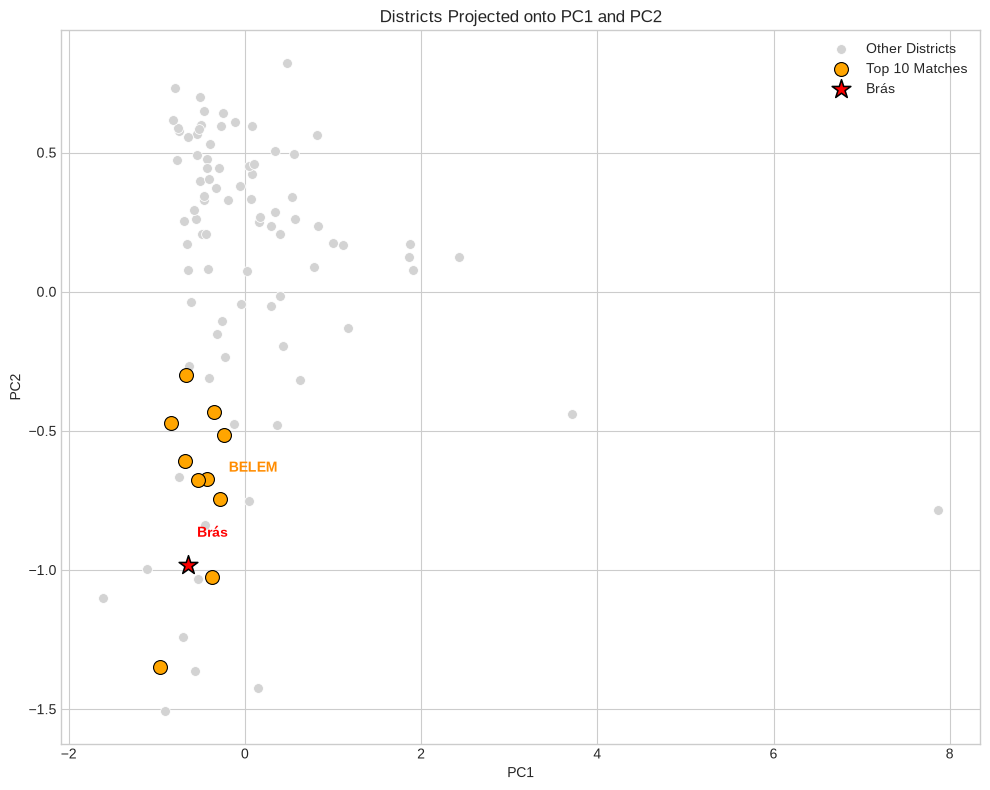

In [89]:
# Calculate PCA scores (projections)
pca_scores = X_centered.dot(Vt.T)
pca_df = pd.DataFrame(pca_scores[:, :2], columns=['PC1', 'PC2'], index=df.index)
pca_df['District'] = df['district_name']

plt.figure(figsize=(10, 8))
# Plot all districts
sns.scatterplot(data=pca_df, x='PC1', y='PC2', color='lightgrey', s=50, label='Other Districts')

# Highlight Top 10
top10_df = pca_df.loc[top_10]
sns.scatterplot(data=top10_df, x='PC1', y='PC2', color='orange', s=100, edgecolor='black', label='Top 10 Matches')

# Highlight Brás
bras_df = pca_df.loc[[bras_id]]
sns.scatterplot(data=bras_df, x='PC1', y='PC2', color='red', s=200, marker='*', edgecolor='black', label='Brás')

# Annotate Brás and Top Match
plt.text(bras_df['PC1'].values[0] + 0.1, bras_df['PC2'].values[0] + 0.1, 'Brás', weight='bold', color='red')
plt.text(top10_df.loc[top_match_id, 'PC1'] + 0.1, top10_df.loc[top_match_id, 'PC2'] + 0.1, top_match_name, weight='bold', color='darkorange')

plt.title('Districts Projected onto PC1 and PC2')
plt.legend()
plt.tight_layout()
plt.show()


In [90]:
import numpy as np
import pandas as pd

# Ensure we have the Brás index position in the array
bras_idx = df.index.get_loc(bras_id)

# Grab the baseline ranks from your earlier 'res' dataframe
baseline_ranks = res['rank']

# Style function
def color_shift(val):
    if pd.isna(val):
        return ''
    color = 'green' if val > 0 else 'red' if val < 0 else 'black'
    return f'color: {color}'

### PCA-Weighted Distance: k=1 Dimension

In [91]:
# 1. Slice the pca_scores array for the first 1 components
pca_k = pca_scores[:, :1]

# 2. Extract Brás PCA scores for 1 components
bras_pca_k = pca_k[bras_idx]

# 3. Calculate Euclidean distance between Brás and all districts
dists = np.linalg.norm(pca_k - bras_pca_k, axis=1)

# Create DataFrame to hold distances
pca_res = pd.DataFrame({'pca_distance': dists}, index=df.index)
pca_res['district_name'] = df['district_name']

# 4. Filter out Brás and sort ascending
pca_res = pca_res.drop(bras_id).sort_values('pca_distance')

# 5. Assign competition rank (method='min')
pca_res['pca_rank'] = pca_res['pca_distance'].rank(method='min').astype(int)

# 6. Calculate Rank Shift (Baseline Rank - New PCA Rank)
pca_res['rank_shift'] = baseline_ranks - pca_res['pca_rank']

# Grab the Top 10 and display for PDF compatibility
top_10 = pca_res[['district_name', 'pca_distance', 'pca_rank', 'rank_shift']].head(10).copy()
top_10['pca_distance'] = top_10['pca_distance'].round(4)
top_10

,district_name,pca_distance,pca_rank,rank_shift
district_id,,,,
20,CARRAO,0.0017,1,21
72,SAO LUCAS,0.0037,2,45
60,PERDIZES,0.0103,3,13
01,AGUA RASA,0.0155,4,20
80,TATUAPE,0.0207,5,1
77,SAUDE,0.0309,6,14
49,LIBERDADE,0.0345,7,0
85,VILA FORMOSA,0.0452,8,23
45,JARDIM PAULISTA,0.0561,9,3


### PCA-Weighted Distance: k=2 Dimensions

In [92]:
# 1. Slice the pca_scores array for the first 2 components
pca_k = pca_scores[:, :2]

# 2. Extract Brás PCA scores for 2 components
bras_pca_k = pca_k[bras_idx]

# 3. Calculate Euclidean distance between Brás and all districts
dists = np.linalg.norm(pca_k - bras_pca_k, axis=1)

# Create DataFrame to hold distances
pca_res = pd.DataFrame({'pca_distance': dists}, index=df.index)
pca_res['district_name'] = df['district_name']

# 4. Filter out Brás and sort ascending
pca_res = pca_res.drop(bras_id).sort_values('pca_distance')

# 5. Assign competition rank (method='min')
pca_res['pca_rank'] = pca_res['pca_distance'].rank(method='min').astype(int)

# 6. Calculate Rank Shift (Baseline Rank - New PCA Rank)
pca_res['rank_shift'] = baseline_ranks - pca_res['pca_rank']

# Grab the Top 10 and display for PDF compatibility
top_10 = pca_res[['district_name', 'pca_distance', 'pca_rank', 'rank_shift']].head(10).copy()
top_10['pca_distance'] = top_10['pca_distance'].round(4)
top_10

,district_name,pca_distance,pca_rank,rank_shift
district_id,,,,
32,MOEMA,0.1186,1,16
56,PARI,0.2348,2,16
45,JARDIM PAULISTA,0.2650,3,9
09,BOM RETIRO,0.2765,4,-2
62,PINHEIROS,0.3239,5,-1
35,ITAIM BIBI,0.3330,6,13
49,LIBERDADE,0.3735,7,0
14,CAMBUCI,0.3767,8,-5
26,CONSOLACAO,0.3897,9,4


### PCA-Weighted Distance: k=3 Dimensions

In [93]:
# 1. Slice the pca_scores array for the first 3 components
pca_k = pca_scores[:, :3]

# 2. Extract Brás PCA scores for 3 components
bras_pca_k = pca_k[bras_idx]

# 3. Calculate Euclidean distance between Brás and all districts
dists = np.linalg.norm(pca_k - bras_pca_k, axis=1)

# Create DataFrame to hold distances
pca_res = pd.DataFrame({'pca_distance': dists}, index=df.index)
pca_res['district_name'] = df['district_name']

# 4. Filter out Brás and sort ascending
pca_res = pca_res.drop(bras_id).sort_values('pca_distance')

# 5. Assign competition rank (method='min')
pca_res['pca_rank'] = pca_res['pca_distance'].rank(method='min').astype(int)

# 6. Calculate Rank Shift (Baseline Rank - New PCA Rank)
pca_res['rank_shift'] = baseline_ranks - pca_res['pca_rank']

# Grab the Top 10 and display for PDF compatibility
top_10 = pca_res[['district_name', 'pca_distance', 'pca_rank', 'rank_shift']].head(10).copy()
top_10['pca_distance'] = top_10['pca_distance'].round(4)
top_10

,district_name,pca_distance,pca_rank,rank_shift
district_id,,,,
09,BOM RETIRO,0.2786,1,1
32,MOEMA,0.2956,2,15
62,PINHEIROS,0.3243,3,1
49,LIBERDADE,0.3871,4,3
45,JARDIM PAULISTA,0.3945,5,7
14,CAMBUCI,0.4004,6,-3
35,ITAIM BIBI,0.4249,7,12
08,BELEM,0.4370,8,-7
56,PARI,0.4586,9,9


### PCA-Weighted Distance: k=4 Dimensions

In [94]:
# 1. Slice the pca_scores array for the first 4 components
pca_k = pca_scores[:, :4]

# 2. Extract Brás PCA scores for 4 components
bras_pca_k = pca_k[bras_idx]

# 3. Calculate Euclidean distance between Brás and all districts
dists = np.linalg.norm(pca_k - bras_pca_k, axis=1)

# Create DataFrame to hold distances
pca_res = pd.DataFrame({'pca_distance': dists}, index=df.index)
pca_res['district_name'] = df['district_name']

# 4. Filter out Brás and sort ascending
pca_res = pca_res.drop(bras_id).sort_values('pca_distance')

# 5. Assign competition rank (method='min')
pca_res['pca_rank'] = pca_res['pca_distance'].rank(method='min').astype(int)

# 6. Calculate Rank Shift (Baseline Rank - New PCA Rank)
pca_res['rank_shift'] = baseline_ranks - pca_res['pca_rank']

# Grab the Top 10 and display for PDF compatibility
top_10 = pca_res[['district_name', 'pca_distance', 'pca_rank', 'rank_shift']].head(10).copy()
top_10['pca_distance'] = top_10['pca_distance'].round(4)
top_10

,district_name,pca_distance,pca_rank,rank_shift
district_id,,,,
09,BOM RETIRO,0.2786,1,1
32,MOEMA,0.2983,2,15
45,JARDIM PAULISTA,0.4094,3,9
14,CAMBUCI,0.4237,4,-1
62,PINHEIROS,0.4254,5,-1
08,BELEM,0.4574,6,-5
56,PARI,0.4633,7,11
49,LIBERDADE,0.5244,8,-1
35,ITAIM BIBI,0.5246,9,10


### PCA-Weighted Distance: k=5 Dimensions

In [95]:
# 1. Slice the pca_scores array for the first 5 components
pca_k = pca_scores[:, :5]

# 2. Extract Brás PCA scores for 5 components
bras_pca_k = pca_k[bras_idx]

# 3. Calculate Euclidean distance between Brás and all districts
dists = np.linalg.norm(pca_k - bras_pca_k, axis=1)

# Create DataFrame to hold distances
pca_res = pd.DataFrame({'pca_distance': dists}, index=df.index)
pca_res['district_name'] = df['district_name']

# 4. Filter out Brás and sort ascending
pca_res = pca_res.drop(bras_id).sort_values('pca_distance')

# 5. Assign competition rank (method='min')
pca_res['pca_rank'] = pca_res['pca_distance'].rank(method='min').astype(int)

# 6. Calculate Rank Shift (Baseline Rank - New PCA Rank)
pca_res['rank_shift'] = baseline_ranks - pca_res['pca_rank']

# Grab the Top 10 and display for PDF compatibility
top_10 = pca_res[['district_name', 'pca_distance', 'pca_rank', 'rank_shift']].head(10).copy()
top_10['pca_distance'] = top_10['pca_distance'].round(4)
top_10

,district_name,pca_distance,pca_rank,rank_shift
district_id,,,,
08,BELEM,0.4606,1,0
09,BOM RETIRO,0.5002,2,0
14,CAMBUCI,0.5756,3,0
62,PINHEIROS,0.6506,4,0
45,JARDIM PAULISTA,0.6596,5,7
53,MOOCA,0.7270,6,-1
49,LIBERDADE,0.7353,7,0
48,LAPA,0.7564,8,0
80,TATUAPE,0.7730,9,-3


### PCA-Weighted Distance: k=6 Dimensions

In [96]:
# 1. Slice the pca_scores array for the first 6 components
pca_k = pca_scores[:, :6]

# 2. Extract Brás PCA scores for 6 components
bras_pca_k = pca_k[bras_idx]

# 3. Calculate Euclidean distance between Brás and all districts
dists = np.linalg.norm(pca_k - bras_pca_k, axis=1)

# Create DataFrame to hold distances
pca_res = pd.DataFrame({'pca_distance': dists}, index=df.index)
pca_res['district_name'] = df['district_name']

# 4. Filter out Brás and sort ascending
pca_res = pca_res.drop(bras_id).sort_values('pca_distance')

# 5. Assign competition rank (method='min')
pca_res['pca_rank'] = pca_res['pca_distance'].rank(method='min').astype(int)

# 6. Calculate Rank Shift (Baseline Rank - New PCA Rank)
pca_res['rank_shift'] = baseline_ranks - pca_res['pca_rank']

# Grab the Top 10 and display for PDF compatibility
top_10 = pca_res[['district_name', 'pca_distance', 'pca_rank', 'rank_shift']].head(10).copy()
top_10['pca_distance'] = top_10['pca_distance'].round(4)
top_10

,district_name,pca_distance,pca_rank,rank_shift
district_id,,,,
08,BELEM,0.4619,1,0
09,BOM RETIRO,0.5161,2,0
14,CAMBUCI,0.5761,3,0
45,JARDIM PAULISTA,0.6808,4,8
62,PINHEIROS,0.6840,5,-1
53,MOOCA,0.7274,6,-1
49,LIBERDADE,0.7377,7,0
48,LAPA,0.7577,8,0
80,TATUAPE,0.7846,9,-3


## Sensitivity Metric: PCA-Weighted Distance

Instead of assigning an equal 1/13 manual weight to each feature family, we can calculate the similarity distance in the **Principal Component Space**. 

By retaining the top principal components that explain 90% of the variance and computing the Euclidean distance along those axes, the similarity score is naturally weighted by the dominant structural and morphological trends of São Paulo.

### Interpreting the PCA Axes
Let's explicitly interpret the actual features driving the variance.


In [97]:
# 1. Interpret PCA Loadings for PC1 and PC2
print("--- INTERPRETING PC1 (Dominant Structural Axis) ---")
pc1_loadings = loadings['PC1'].sort_values(ascending=False)
print("Strongest Positive Drivers:")
print(pc1_loadings.head(3).to_string())
print("\nStrongest Negative Drivers:")
print(pc1_loadings.tail(3).sort_values().to_string())

print("\n--- INTERPRETING PC2 (Secondary Structural Axis) ---")
pc2_loadings = loadings['PC2'].sort_values(ascending=False)
print("Strongest Positive Drivers:")
print(pc2_loadings.head(3).to_string())
print("\nStrongest Negative Drivers:")
print(pc2_loadings.tail(3).sort_values().to_string())

# 2. Find components to reach 90% variance
k_components = np.argmax(cumulative_var >= 0.90) + 1
print(f"\nRetaining {k_components} principal components out of {len(X[0])} to capture >= 90% of the variance.")

# 3. Compute Distance in Retained PCA Space
pca_retained = pca_scores[:, :k_components]

pca_distances = []
bras_pca_idx = df.index.get_loc(bras_id)
bras_pca_vector = pca_retained[bras_pca_idx]

for i in range(len(pca_retained)):
    # Euclidean distance in PCA space
    dist = np.sqrt(np.sum((pca_retained[i] - bras_pca_vector)**2))
    pca_distances.append(dist)

# 4. Rank and Display
pca_res = pd.DataFrame({'pca_distance': pca_distances}, index=df.index)
pca_res['district_name'] = df['district_name']
pca_res = pca_res.drop(bras_id).sort_values('pca_distance')
pca_res['pca_rank'] = pca_res['pca_distance'].rank(method='min').astype(int)

print("\n--- TOP 10 MATCHES USING PCA-WEIGHTED DISTANCE ---")
display(pca_res[['district_name', 'pca_distance', 'pca_rank']].head(10))

# Compare against Equal Weight Rank
print("\nComparison of Ranks (Equal Weight vs PCA):")
comparison = pca_res[['district_name', 'pca_rank']].head(10).copy()
comparison['equal_weight_rank'] = res.loc[comparison.index, 'rank']
comparison['rank_shift'] = comparison['equal_weight_rank'] - comparison['pca_rank']
display(comparison)


--- INTERPRETING PC1 (Dominant Structural Axis) ---
Strongest Positive Drivers:
block_log_area_iqr       0.182652
block_log_area_median    0.075372
block_compactness_iqr    0.053626

Strongest Negative Drivers:
street_density_km_km2                       -0.427589
formal_job_density_area_first_km2           -0.402294
street_class_model_share_via_de_pedestres   -0.390905

--- INTERPRETING PC2 (Secondary Structural Axis) ---
Strongest Positive Drivers:
formal_job_density_area_first_km2            0.280702
intersection_density_proxy_5m_km2            0.275291
street_class_model_share_via_de_pedestres    0.152172

Strongest Negative Drivers:
street_class_model_share_local      -0.547550
street_class_model_share_arterial   -0.362690
street_class_model_share_rodovia    -0.322692

Retaining 5 principal components out of 23 to capture >= 90% of the variance.

--- TOP 10 MATCHES USING PCA-WEIGHTED DISTANCE ---


,district_name,pca_distance,pca_rank
district_id,,,
08,BELEM,0.460577,1
09,BOM RETIRO,0.500181,2
14,CAMBUCI,0.575644,3
62,PINHEIROS,0.650569,4
45,JARDIM PAULISTA,0.659600,5
53,MOOCA,0.727012,6
49,LIBERDADE,0.735265,7
48,LAPA,0.756448,8
80,TATUAPE,0.773027,9



Comparison of Ranks (Equal Weight vs PCA):


,district_name,pca_rank,equal_weight_rank,rank_shift
district_id,,,,
08,BELEM,1,1,0
09,BOM RETIRO,2,2,0
14,CAMBUCI,3,3,0
62,PINHEIROS,4,4,0
45,JARDIM PAULISTA,5,12,7
53,MOOCA,6,5,-1
49,LIBERDADE,7,7,0
48,LAPA,8,8,0
80,TATUAPE,9,6,-3


## Validation: Ward Hierarchical Clustering

To validate the similarity findings, we apply Ward hierarchical clustering on the properly weighted primary embedding. This will allow us to see if Brás and its top matches naturally fall into the same urban typology cluster.


--- WARD CLUSTERING: SILHOUETTE SCORES ---
k=3 clusters: Silhouette Score = 0.5205
k=4 clusters: Silhouette Score = 0.3186
k=5 clusters: Silhouette Score = 0.2731
k=6 clusters: Silhouette Score = 0.2651
k=7 clusters: Silhouette Score = 0.2676
k=8 clusters: Silhouette Score = 0.2663

Optimal number of clusters (highest silhouette score): 3

Brás is in Cluster 0. Other districts in this cluster:


,district_name,equal_weight_rank
district_id,,
10,BRAS,0.0
08,BELEM,1.0
09,BOM RETIRO,2.0
14,CAMBUCI,3.0
62,PINHEIROS,4.0
...,...,...
57,PARQUE DO CARMO,85.0
65,RAPOSO TAVARES,86.0
42,JARAGUA,87.0


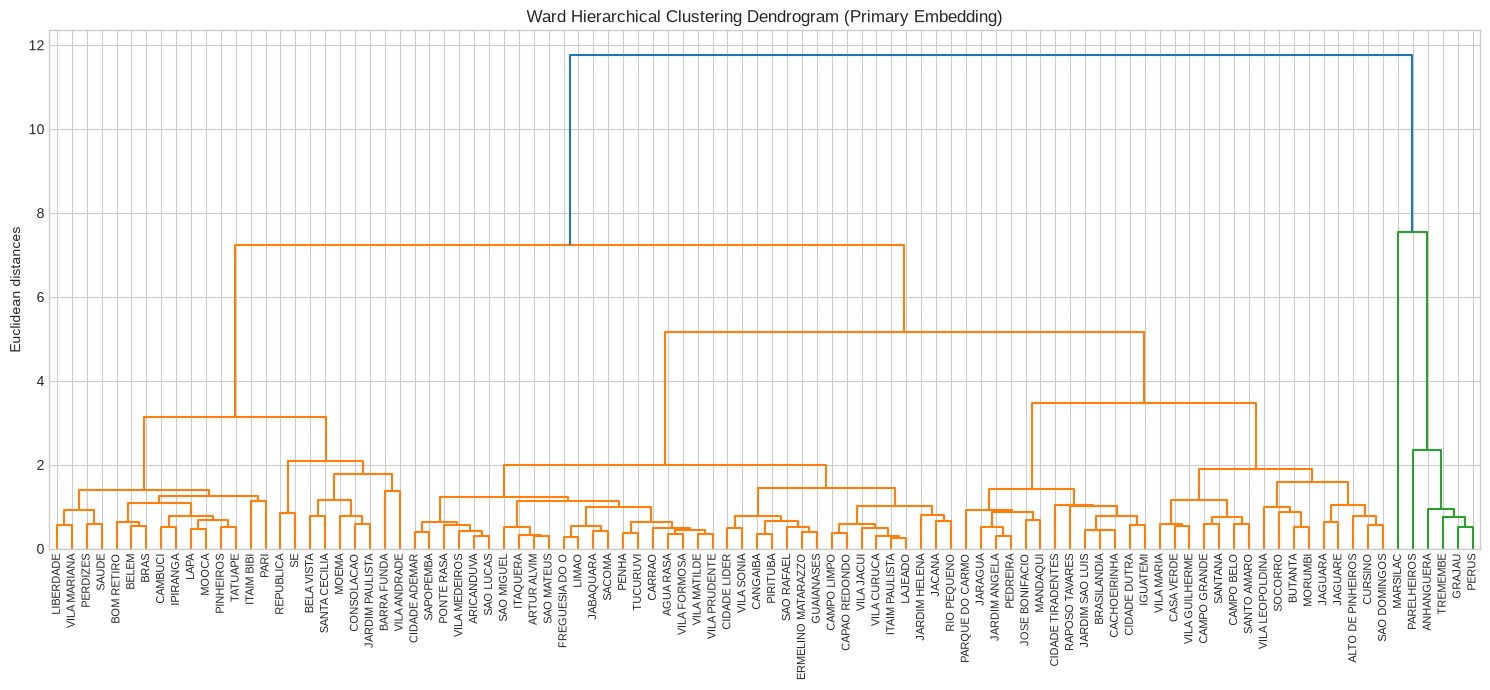

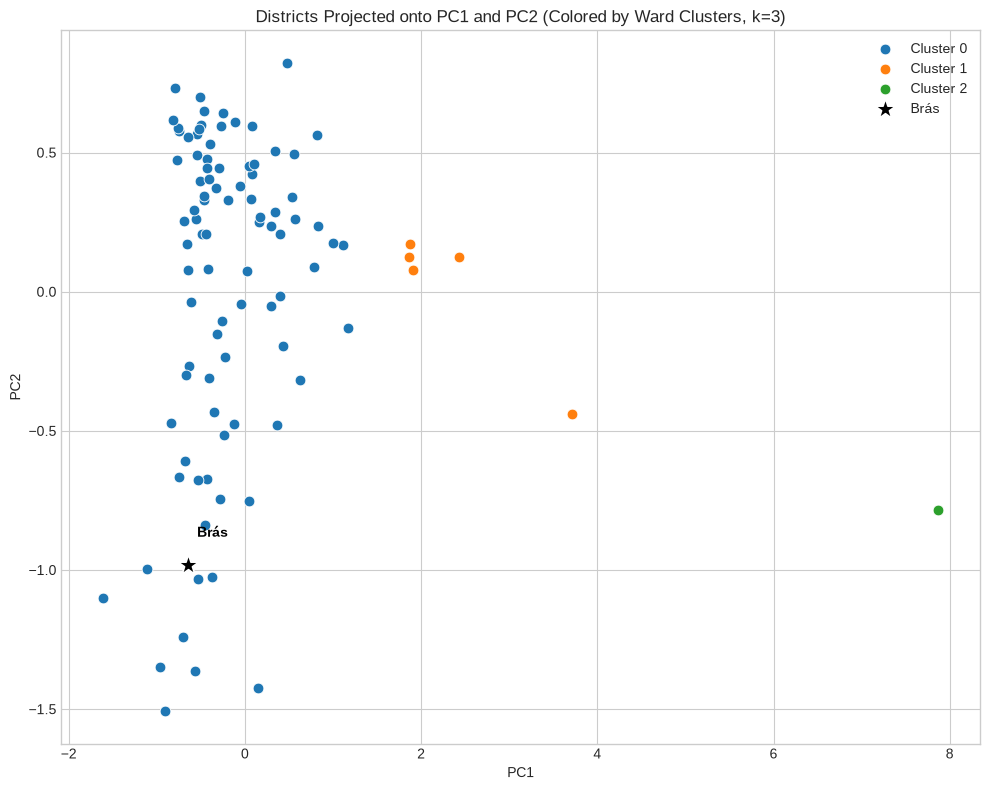

In [98]:
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score
import scipy.cluster.hierarchy as sch

# Iterate through k=3 to 8 as specified in the implementation plan
print("\n--- WARD CLUSTERING: SILHOUETTE SCORES ---")
silhouette_scores = {}
for k in range(3, 9):
    ward = AgglomerativeClustering(n_clusters=k, linkage='ward')
    labels = ward.fit_predict(E_df.values)
    score = silhouette_score(E_df.values, labels)
    silhouette_scores[k] = score
    print(f"k={k} clusters: Silhouette Score = {score:.4f}")

# Choose the k with the highest silhouette score
best_k = max(silhouette_scores, key=silhouette_scores.get)
print(f"\nOptimal number of clusters (highest silhouette score): {best_k}")

# Fit final model with best_k
ward_final = AgglomerativeClustering(n_clusters=best_k, linkage='ward')
cluster_labels = ward_final.fit_predict(E_df.values)

# Add cluster labels to our DataFrame
df['cluster'] = cluster_labels

# 1. Analyze Brás's Cluster
bras_cluster = df.loc[bras_id, 'cluster']
print(f"\nBrás is in Cluster {bras_cluster}. Other districts in this cluster:")
bras_cluster_members = df[df['cluster'] == bras_cluster][['district_name']].copy()
bras_cluster_members['equal_weight_rank'] = res['rank']
# Fill rank 0 for Brás itself
bras_cluster_members.loc[bras_id, 'equal_weight_rank'] = 0
bras_cluster_members = bras_cluster_members.sort_values('equal_weight_rank')
display(bras_cluster_members)

# 2. Plot Dendrogram
plt.figure(figsize=(15, 7))
plt.title('Ward Hierarchical Clustering Dendrogram (Primary Embedding)')
dendrogram = sch.dendrogram(sch.linkage(E_df.values, method='ward'), 
                            labels=df['district_name'].values,
                            leaf_rotation=90, 
                            leaf_font_size=8)
plt.ylabel('Euclidean distances')
plt.tight_layout()
plt.show()

# 3. Plot PCA with Cluster Labels
pca_df['cluster'] = cluster_labels
plt.figure(figsize=(10, 8))
# We use a distinct color palette for the clusters
palette = sns.color_palette('tab10', n_colors=best_k)

for c in range(best_k):
    cluster_data = pca_df[pca_df['cluster'] == c]
    sns.scatterplot(data=cluster_data, x='PC1', y='PC2', color=palette[c], s=60, label=f'Cluster {c}')

# Highlight Brás
sns.scatterplot(data=bras_df, x='PC1', y='PC2', color='black', s=250, marker='*', edgecolor='white', label='Brás')
plt.text(bras_df['PC1'].values[0] + 0.1, bras_df['PC2'].values[0] + 0.1, 'Brás', weight='bold', color='black')

plt.title(f'Districts Projected onto PC1 and PC2 (Colored by Ward Clusters, k={best_k})')
plt.legend()
plt.tight_layout()
plt.show()